## The Perceptron

The simplest model of a neuron is that it takes a number of inputs, and when the total stimulus reaches a certain threshold, the neuron "fires" (sends out an electronic signal to another neuron).

Mathematically, we can model it in the following way:

$$y=\sum_{i = 1}^{n} {w_i x_i} = \vec{w} \cdot \vec{x} \tag {1}$$

where the $(x_1, x_2, ..., x_n)$ are the inputs, with different weights $(w_1, w_2, ..., w_n)$ for each of them, and $y$ is the total stimulus.

(In coding, $\vec{w}$ and $\vec{x}$ will be implemented as numpy arrays.)

The weighted sum $y$ of these inputs is then compared with a threshold, sometimes represented by step function:


$$z(y) = \begin{cases} 
      0 & y\leq 0 \\
      1 & y\gt 0
\end{cases} \tag {2}$$

Really, $z$ is a function of $\vec{x}$ and the weights, $\vec{w}$, $z(\vec{x}, \vec{w})$.

We then compare $z$ with a desired output: $d(\vec{x})$ (which obviously depends on the input, but not the weights).

Depending on how $z$ is different from $d$, we will adjust the weights to move $z$ closer and closer to $d$.  This process is called "training" (the weights).

This is what we call a *perceptron*.

Once a perceptron is trained, it can then produce an output given a set of previously unseen inputs.

## Homework PDF (inline)

This notebook can display the homework PDF **inside** the notebook (no conversion needed).

If the PDF is in the **same folder** as this notebook, the code will find it automatically. Otherwise, set `pdf_path` manually.

In [2]:
from pathlib import Path
from IPython.display import IFrame, display

# Try to locate the PDF near this notebook (works if you keep the PDF next to the .ipynb)
candidates = [
    Path("PHYS303_HW01.pdf"),
    Path.cwd() / "PHYS303_HW01.pdf",
]

pdf_path = next((p for p in candidates if p.exists()), None)

if pdf_path is None:
    raise FileNotFoundError(
        "Couldn't find PHYS303_HW01.pdf. Put it in the same folder as this notebook, "
        "or edit `candidates` / set `pdf_path` to the correct location."
    )

display(IFrame(str(pdf_path), width=950, height=650))

### Optional: show pages as images (only if you need it)

If you want each PDF page as an image (e.g., to annotate figures), you can use `pdf2image`.
On macOS you also need Poppler:

```bash
brew install poppler
```

Then in Python (you may need to set `poppler_path`):
```python
from pdf2image import convert_from_path

pages = convert_from_path("PHYS303_HW01.pdf", poppler_path="/opt/homebrew/bin")
for p in pages:
    display(p)
```

## There is one problem:

When the threshold function $z$ is written in the form of (2), $\vec{x} = 0$ is necessarily at the boundary.  This may or may not be desirable.

## The fix: Introducing the bias, $b$,

$$
y=\sum_{i}^{n} {w_i x_i} + b = \vec{w} \cdot \vec{x} + b\tag {3}
$$


Then, 
$$
z(y) = z(\vec{x}, \vec{w}; b) = \begin{cases}
      0 & y\leq 0 \\
      1 & y\gt 0
\end{cases} \tag{4}$$

The bias shifts the (threshold, or decision) boundary away from the origin and is independent on any input value.

## Conceptually, it's clearer to think of the problem in this way and treat the inputs and the bias distinctly.

## However, mathematically (and numerically):

*It's more convenient to implement the bias as an addition input with a constant value of 1.  Assign a weight for this (fake) input, then the weight is the same as the bias; $b$.*

## Simple Example:

## A perceptron that performs the AND operation on two inputs:

| $x_1$ | $x_2$ | $z$   |
|:-:    |:-:    |:-:    |   
|   0   |   0   |   0   |
|   0   |   1   |   0   |
|   1   |   0   |   0   |
|   1   |   1   |   1   |

 



## You'd think in this case, two inputs, $x_1$ and $x_2$ would be enough...

But acutally we need the bias.  Let's implement it as the third input; call it $x_3$ with an associated weight $w_3$.  You don't care about $w_3$ -- it's only there to help you achieve the desired outcome. 



In [3]:
%matplotlib inline
# All imports
from random import choice
import numpy as np
import matplotlib.pyplot as plt


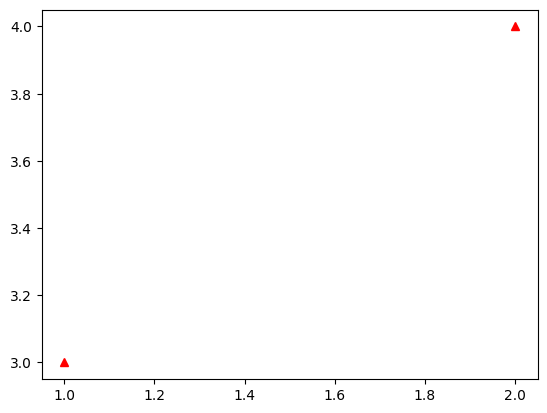

In [4]:
lst = [1, 2]
x = np.array(lst)
lst = [3, 4]
y = np.array(lst)

plt.plot(x, y, 'r^')
plt.show()

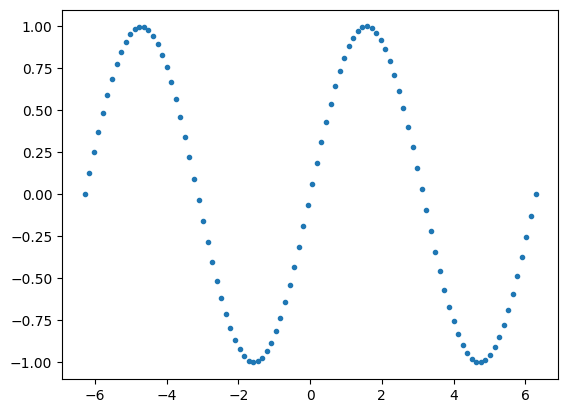

In [5]:
n = 100

x = np.linspace(-2 * np.pi, 2 * np.pi, n)
y = np.sin(np.array(x))

plt.plot(x, y, '.')
plt.show()

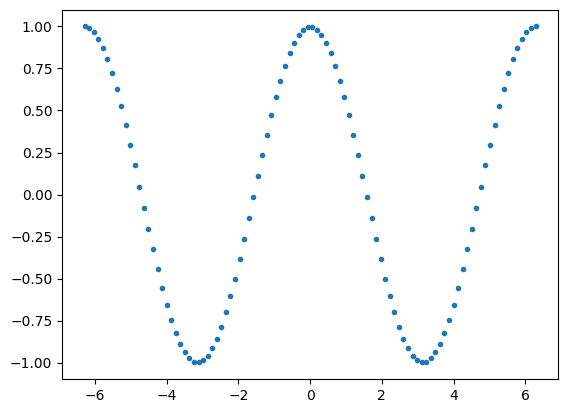

In [6]:
n = 100

x = np.linspace(-2 * np.pi, 2 * np.pi, n)
y = np.cos(np.array(x))

plt.plot(x, y, '.')
plt.show()

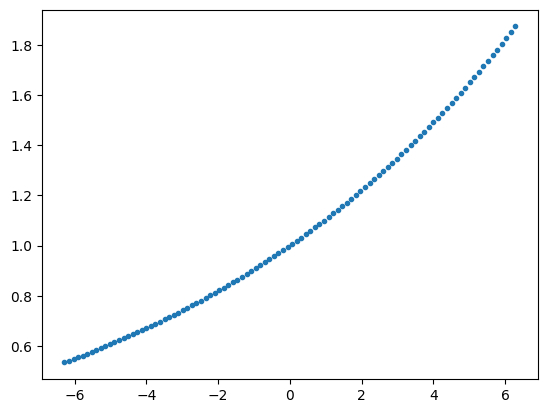

In [7]:
n = 100

x = np.linspace(-2 * np.pi, 2 * np.pi, n)
y = np.power(np.e, np.array(x)/10)

plt.plot(x, y, '.')
plt.show()

## Mini-breakout:
- ## Write a python function that is the step function; call it step_function.
- ## Turn it into a lambda function; call it step_fn. 
- ## Modify your lambda function and call it step_fun so that you can plot it for x between -10 and 10, say.

In [8]:
def step_function(x):
  return np.where(x < 0, 0, 1)

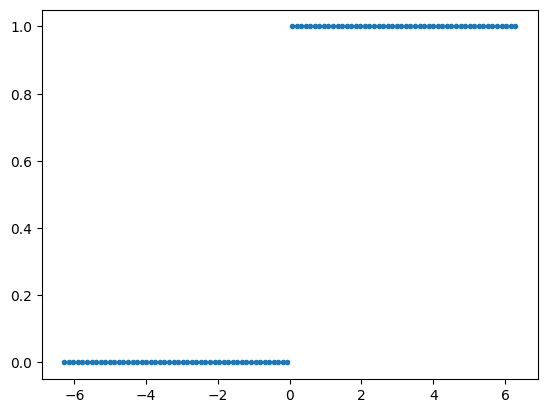

In [9]:
n = 100

x = np.linspace(-2 * np.pi, 2 * np.pi, n)
y = step_function(x)

plt.plot(x, y, '.')
plt.show()

In [10]:
step_fun = lambda x: x >= 0

## Let's turn this into a classifier!!

## Breakout: Try 20 pairs of random numbers between [0, 1]

- ## Classify them according their "z" value.

- ## Plot them, with color coding according their "z" value.


x=(0.549, 0.715) -> z=1
x=(0.603, 0.545) -> z=1
x=(0.424, 0.646) -> z=1
x=(0.438, 0.892) -> z=1
x=(0.964, 0.383) -> z=1
x=(0.792, 0.529) -> z=1
x=(0.568, 0.926) -> z=1
x=(0.071, 0.087) -> z=0
x=(0.020, 0.833) -> z=0
x=(0.778, 0.870) -> z=1
x=(0.979, 0.799) -> z=1
x=(0.461, 0.781) -> z=1
x=(0.118, 0.640) -> z=0
x=(0.143, 0.945) -> z=1
x=(0.522, 0.415) -> z=0
x=(0.265, 0.774) -> z=1
x=(0.456, 0.568) -> z=1
x=(0.019, 0.618) -> z=0
x=(0.612, 0.617) -> z=1
x=(0.944, 0.682) -> z=1


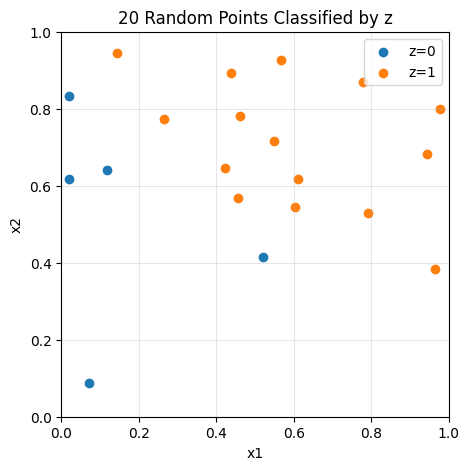

In [18]:
# Breakout: 20 random pairs in [0, 1]
np.random.seed(0)

n = 20
X = np.random.rand(n, 2)

# Perceptron parameters (example)
w = np.array([1.0, 1.0])
b = -1.0  # decision boundary: x1 + x2 = 1

# Classify by z = step(w·x + b)
step_fun = lambda y: (y > 0).astype(int)

y = X @ w + b
z = step_fun(y)

# Show classifications
for (x1, x2), zi in zip(X, z):
    print(f"x=({x1:.3f}, {x2:.3f}) -> z={zi}")

# Plot with color coding by z
plt.figure(figsize=(5, 5))
plt.scatter(X[z == 0, 0], X[z == 0, 1], c='tab:blue', label='z=0')
plt.scatter(X[z == 1, 0], X[z == 1, 1], c='tab:orange', label='z=1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('20 Random Points Classified by z')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## Breakout: Try 100 pairs of random numbers between [0, 1]

- ## Classify them according their "z" value.

- ## Plot them, with color coding according their "z" value.

- ## Plot the four training points using large symbols, also color coded according their "z" values.  For inspiration:

       http://matplotlib.org/api/pyplot_api.html

- ## Plot the decision boundary (a line) using w.

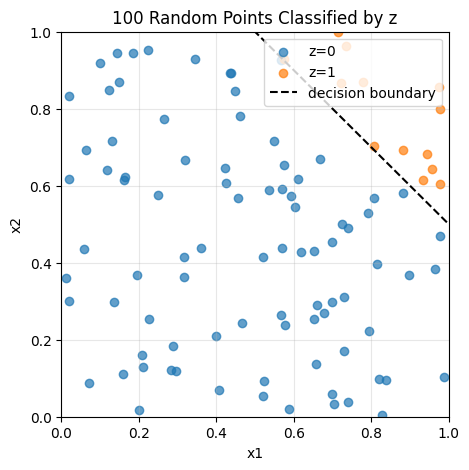

In [24]:
# Breakout: 100 random pairs in [0, 1]
np.random.seed(0)

n = 100
X = np.random.rand(n, 2)

# Training data (AND) with bias x3 = 1
training_data = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1],
])

# Weights (including bias weight as w3)
# AND can be represented by w = [1, 1, -1.5]
w = np.array([1.0, 1.0, -1.5])

step_fun = lambda y: (y > 0).astype(int)

# Classify random points
Xb = np.c_[X, np.ones(n)]  # add bias input

y = Xb @ w
z = step_fun(y)

# Plot random points colored by z
plt.figure(figsize=(5, 5))
plt.scatter(X[z == 0, 0], X[z == 0, 1], c='tab:blue', label='z=0', alpha=0.7)
plt.scatter(X[z == 1, 0], X[z == 1, 1], c='tab:orange', label='z=1', alpha=0.7)


# Plot decision boundary: w1*x1 + w2*x2 + w3 = 0
# => x2 = -(w1/w2) * x1 - w3/w2
x1_line = np.array([0, 1])
if w[1] != 0:
    x2_line = -(w[0] / w[1]) * x1_line - (w[2] / w[1])
    plt.plot(x1_line, x2_line, 'k--', label='decision boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('100 Random Points Classified by z')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()



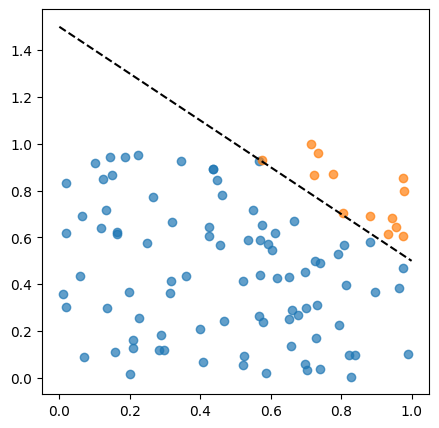

In [ ]:
np.random.seed(0)

n = 100
X = np.random.rand(n, 2)

training_data = np.array([
    [0, 0, 1], 1
    [1, 0, 1], 0
    [1, 1, 1], 0
])

# Weights (including bias weight as w3)
# AND can be represented by w = [1, 1, -1.5]
w = np.array([1.0, 1.0, -1.5])

step_fun = lambda y: (y > 0).astype(int)

# Classify random points
Xb = np.c_[X, np.ones(n)]  # add bias input

y = Xb @ w
z = step_fun(y)

# Plot random points colored by z
plt.figure(figsize=(5, 5))
plt.scatter(X[z == 0, 0], X[z == 0, 1], c='tab:blue', label='z=0', alpha=0.7)
plt.scatter(X[z == 1, 0], X[z == 1, 1], c='tab:orange', label='z=1', alpha=0.7)

x1_line = np.array([0, 1])
x2_line = -(w[0] * x1_line + w[2]) / w[1]
plt.plot(x1_line, x2_line, 'k--', label='decision boundary')

## Breakout: Generate 100 pairs of random numbers between [-10, 10]

- ## Classify them according their "z" value.

- ## Plot them, with color coding according their "z" value.

- ## Plot the decision boundary (a line) using w.

## Breakout: A general perceptron classifier:

      perceptron_classifier(training_data, x, show_train=False)

## Truth Table for OR:
| $x_1$ | $x_2$ | $z$   |
|:-:    |:-:    |:-:    |   
|   0   |   0   |   0   |
|   0   |   1   |   1   |
|   1   |   0   |   1   |
|   1   |   1   |   1   |

## XOR: 

## Exclusive OR is a logical operation that outputs true only when inputs differ (one is true, the other is false).

## Truth Table for XOR
| $x_1$ | $x_2$ | $z$   |
|:-:    |:-:    |:-:    |   
|   0   |   0   |   0   |
|   0   |   1   |   1   |
|   1   |   0   |   1   |
|   1   |   1   |   0   |

# End of Week 4-1

In [12]:
'''
Perceptron to implement the NOR operation

With combined error.

'''
import numpy as np
import random

def choice(arr):
    return random.choice(arr)

step_fun = lambda x: x >= 0

training_data = [
    (np.array([0,0,1]), 1),
    (np.array([0,1,1]), 0),
    (np.array([1,0,1]), 0),
    (np.array([1,1,1]), 0),
]

# usu. random numbers for weights is not a bad starting point
w = np.random.rand(3)*10
errors = []
ws0 = []
ws1 = []
ws2 = []

# "learning rate"
alfa = 0.3  # if w initial values are given a range 10x larger, use larger alpha and 200 steps

# use 100 training steps
n = 200
# w.history = []
for i in range(n):
    # "stochastic"
    x, target = choice(training_data)
    
    y = np.dot(w, x)
    z = step_fun(y)
    error = target - z
    errors.append(error)
    w += alfa * error * x
    ws0.append(w[0])
    ws1.append(w[1])
    ws2.append(w[2])

print('Trained weights (last one is for the bias): {}\n'.format(w))
    
# sanity check: applying trained perceptron to the training data -- it ought to work!
for x, _ in training_data:
    y = np.dot(x, w)
    # not printing the input associated with the bias, x[3], which is always 1.
    print("{}: {:.4f} -> {:d}".format(x[:2], y, step_fun(y)))

Trained weights (last one is for the bias): [-0.90492099 -0.42968046  0.07631196]

[0 0]: 0.0763 -> 1
[0 1]: -0.3534 -> 0
[1 0]: -0.8286 -> 0
[1 1]: -1.2583 -> 0


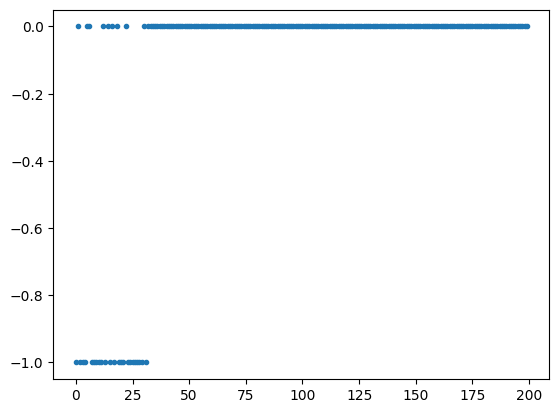

In [13]:
import matplotlib.pyplot as plt

plt.plot(errors, '.')
plt.show()

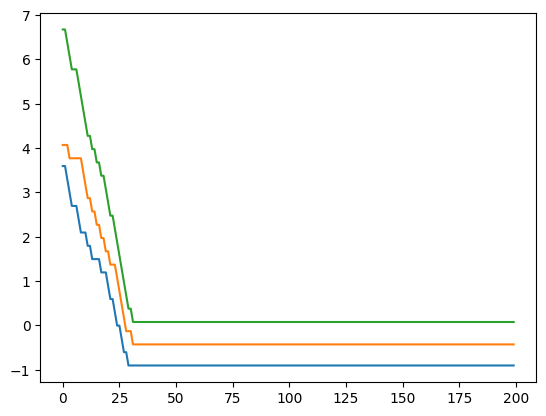

In [14]:
import matplotlib.pyplot as plt

plt.plot(ws0)
plt.plot(ws1)
plt.plot(ws2)
plt.show()

In [ ]:
def clf(x, training_data = training_data):
    x_unkown = [0.5, 0.5]
z = clf(x_unkown, w_trained = wtrained)
print(z)

NameError: name 'w_trained' is not defined

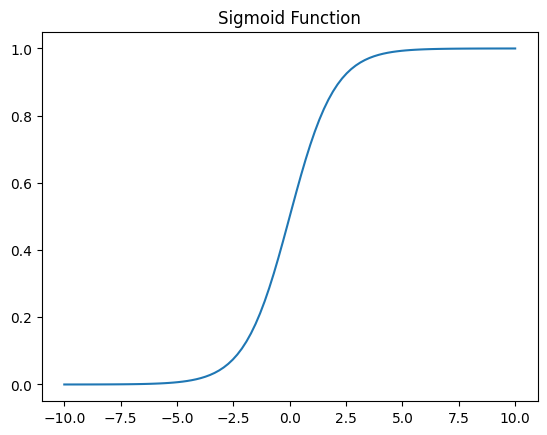

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.plot(x, y)
plt.title("Sigmoid Function")
plt.show()


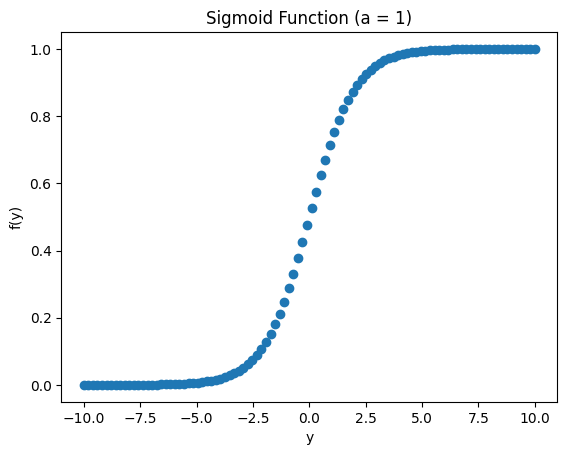

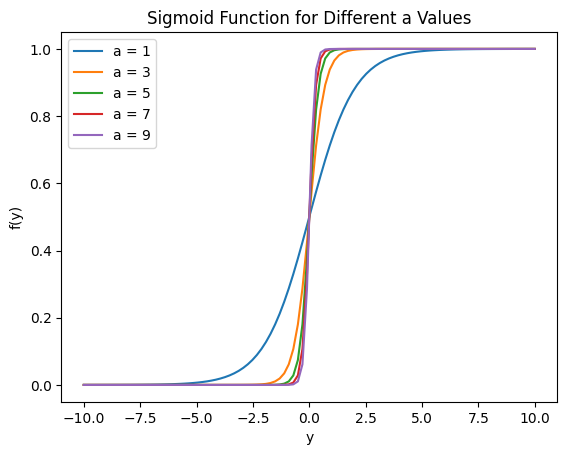

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(y, a=1):
    return 1 / (1 + np.exp(-a * y))


y = np.linspace(-10, 10, 100)

plt.figure()
plt.scatter(y, sigmoid(y))   # dots
plt.title("Sigmoid Function (a = 1)")
plt.xlabel("y")
plt.ylabel("f(y)")
plt.show()

a_values = [1, 3, 5, 7, 9]

plt.figure()

for a in a_values:
    plt.plot(y, sigmoid(y, a), label=f"a = {a}")

plt.title("Sigmoid Function for Different a Values")
plt.xlabel("y")
plt.ylabel("f(y)")
plt.legend()

plt.show()
